In [2]:
pip install pycirclize

Note: you may need to restart the kernel to use updated packages.


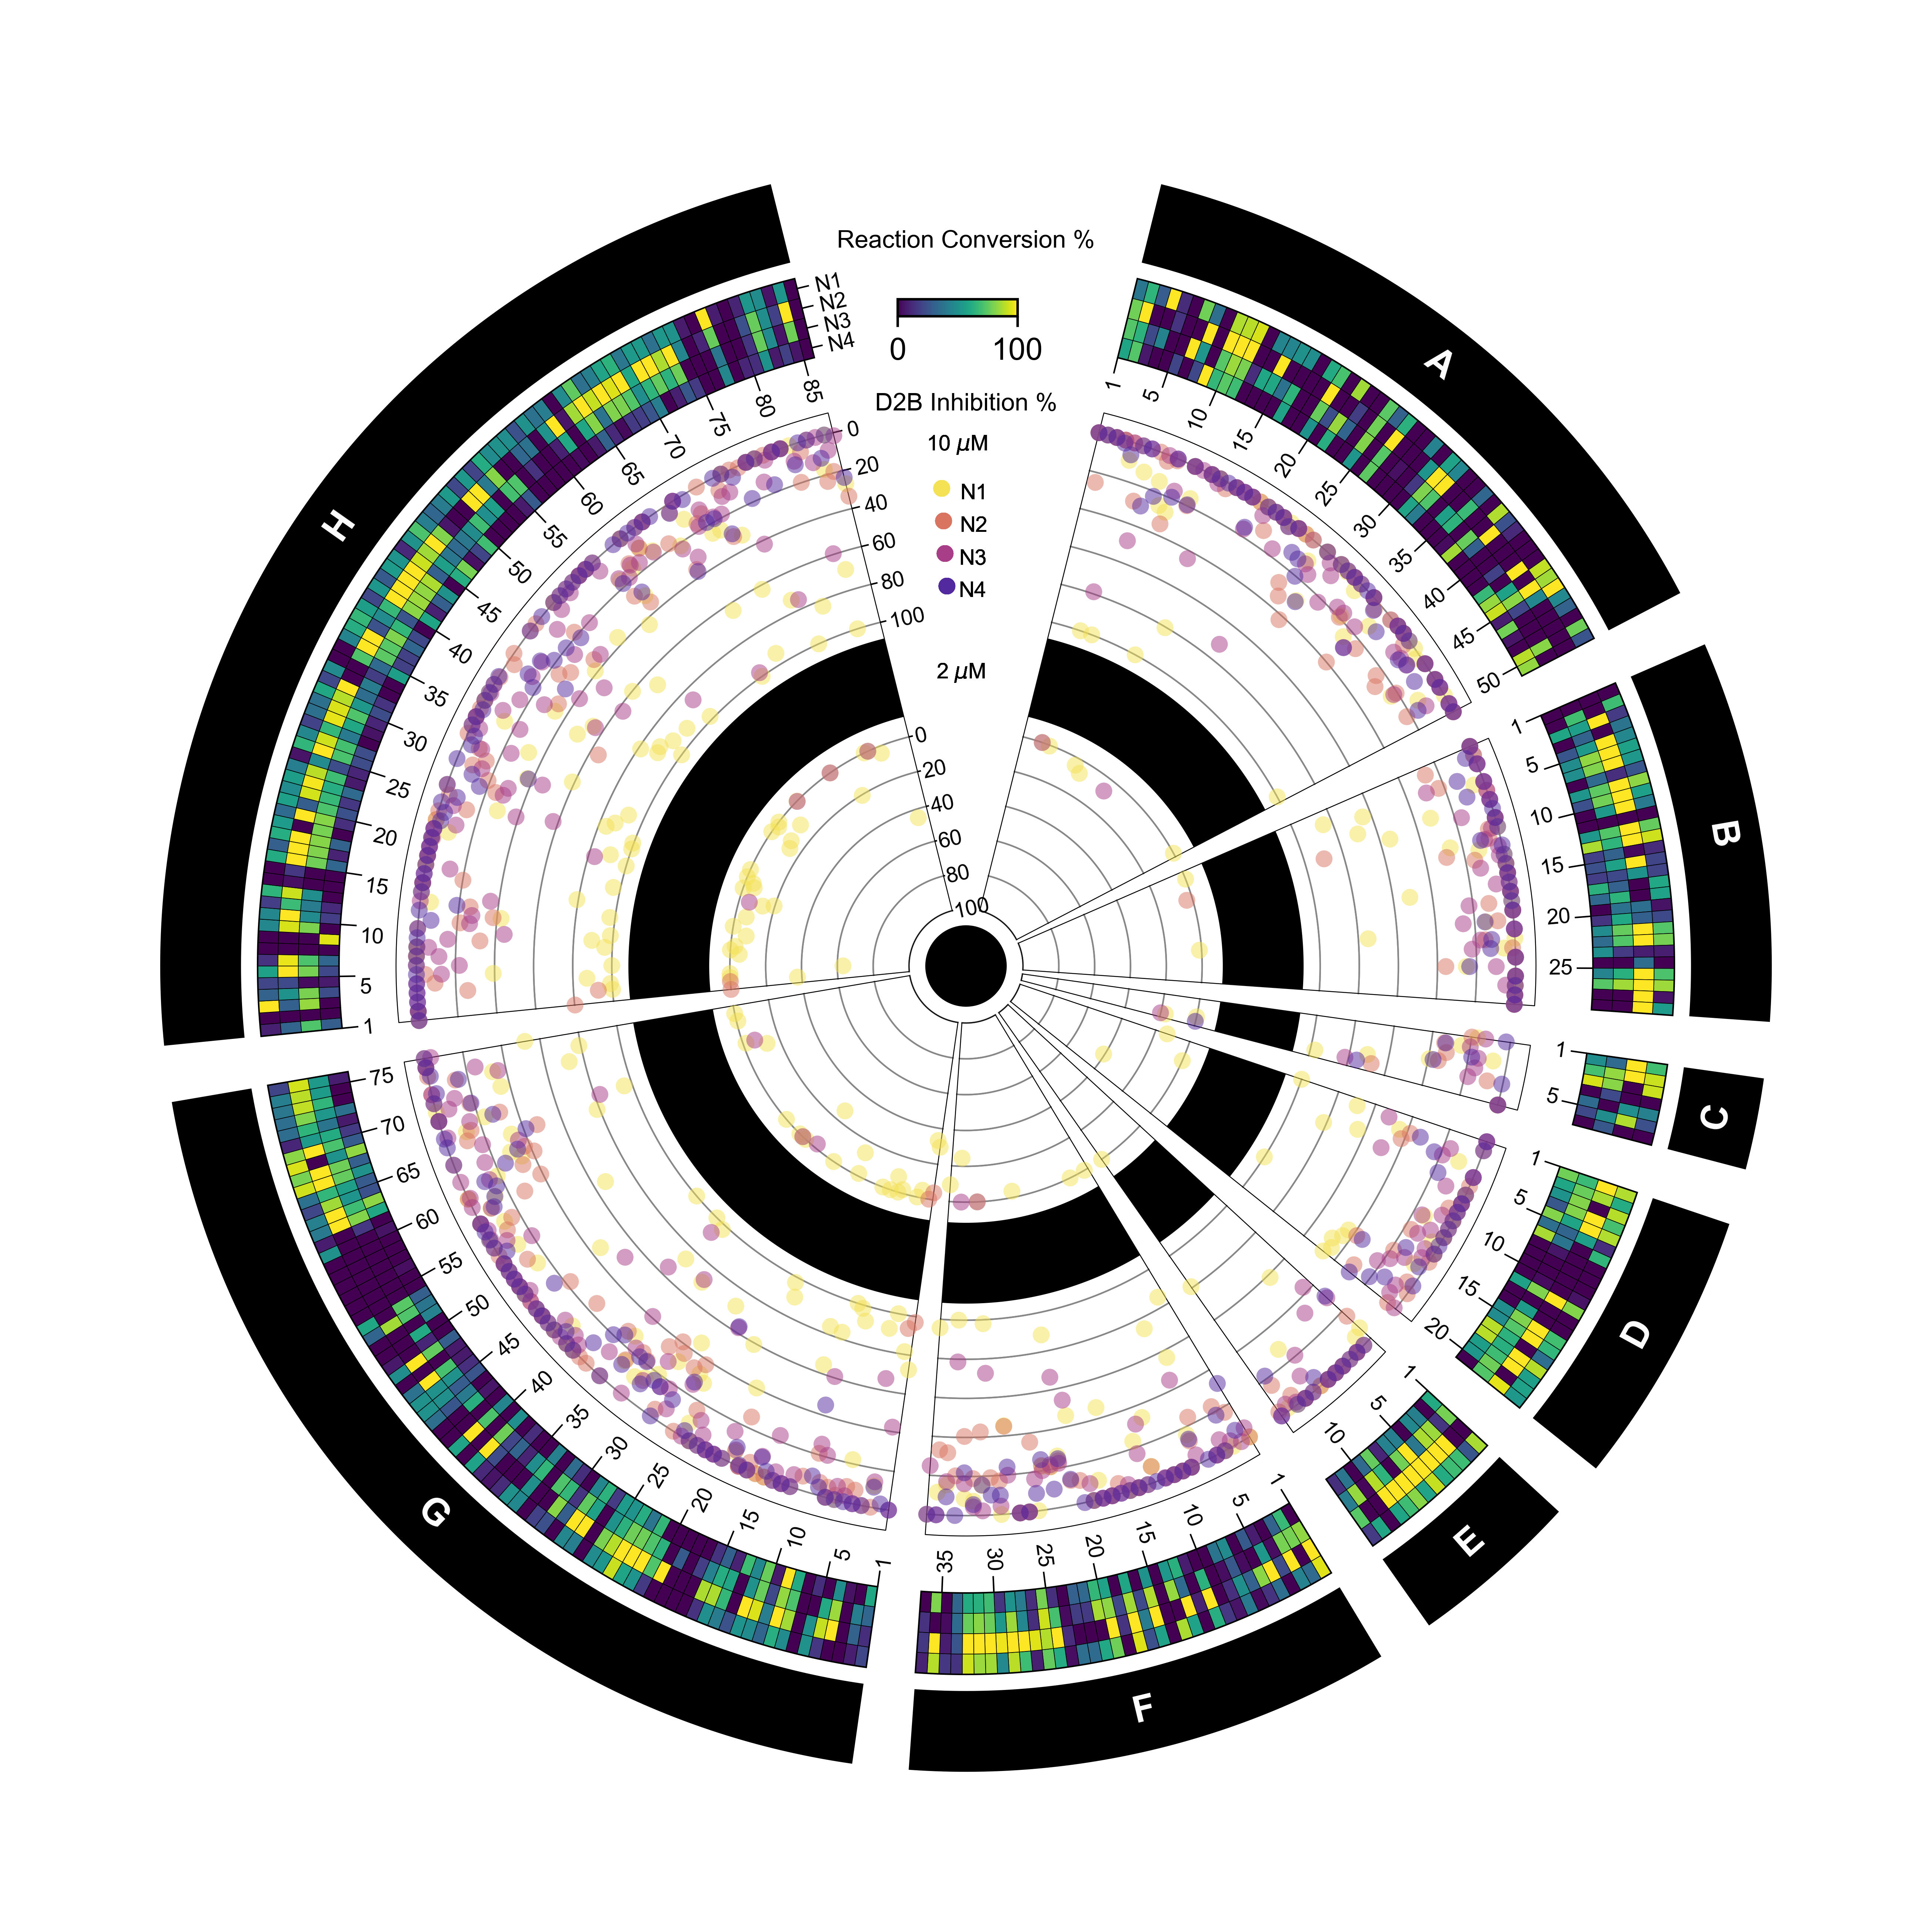

In [4]:
from pycirclize import Circos
import numpy as np

import pandas as pd
import re
import pandas as pd
from pycirclize import Circos
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(0)
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")


plt.rcParams['font.family'] = 'Arial'
def extract_number(value):
    match = re.search(r'(\d+)', value)
    return int(match.group(1)) if match else float('inf')

def scale_array(input_array, old_min, old_max, new_min, new_max):
    # Perform the scaling
    scaled_array = ((input_array - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Convert scaled values to nearest integers
    scaled_array = np.round(scaled_array).astype(int)
    
    return scaled_array


data_df2 = pd.read_csv('yk-1536-4-for_circos.csv')
acid_df = {}
i = 0
for x in data_df2['acid type'].unique():
    dddf = data_df2[data_df2['acid type']==x]
    #dddf.to_csv(f'acid_type_{x}.csv', index=None)
    acid_df['ABCDEFGH'[i]] = dddf
    i+=1

data_df2 = data_df2[['N', 'E', 'inhibition %', 'inhibition % in 5-fold dilution','prod/(nu+prod)*100']]
data_df2.columns = ["from", "to", "value",'value2', 'prod/(nu+prod)*100']



# Initialize Circos
sectors = {acid:len(dfi)//4 for acid,dfi in acid_df.items()}
circos  = Circos(sectors, space=4, start=14, end=346, endspace=False)
Icircos = Circos(sectors, space=0)


#sectors = {"A": 4, "B": 320}
#circos = Circos(sectors, space = 10)
vmin1, vmax1 = 0, 10
vmin2, vmax2 = -100, 100


df_all_new_figure = []
#sector = circos.sectors[0]
counter = 0 
for sector in circos.sectors:
    sector_names = 'ABCDEFGH'
    ############################# LOAD DATA #########################
    data_df = acid_df[sector.name]
    acid_starter = 14
    
     #sector = circos.sectors[1]
    # # Extract 'inhibition %' for link coloring
    color_data = np.array(data_df['inhibition %'].to_list())
    color_data_2um = np.array(data_df['inhibition % in 5-fold dilution'].to_list()) #2um    
    # # Extract data for outer circle heatmap ('prod/(nu+prod)*100')
    heatmap_data = np.array(data_df['prod/(nu+prod)*100'].to_list())
    # # Add outer circle heatmap track
    heatmap_values = heatmap_data  # Ensure this is aligned with the outer circle segments
    norm_heatmap_values = (heatmap_values - heatmap_values.min()) / (100 - heatmap_values.min())
    
    color_data_values = color_data  # Ensure this is aligned with the outer circle segments
    norm_color_values = (color_data_values - color_data_values.min()) / (100 - color_data_values.min())
    
    data_df['norm_heatmap_values'] = heatmap_data
    data_df['norm_color_values'] = norm_color_values
    data_df['color_data_10um'] = color_data
    data_df['color_data_2um'] = color_data_2um
    
    font_size = 7
    l = []
    m = []
    mmm = []
    mmmm = []
    row_names = sorted(data_df['N'].unique(), key=extract_number)
    for x in row_names:
        l.append(data_df[data_df['N'] == x]['norm_heatmap_values'].to_list())
        m.append(data_df[data_df['N'] == x]['norm_color_values'].to_list())
        mmmm.append([float(x) for x in data_df[data_df['N'] == x]['color_data_10um'].to_list()])
        mmm.append([float(x) for x in data_df[data_df['N'] == x]['color_data_2um'].to_list()])
    
    
    mm = []
    for x in list(set(data_df['acid type'].to_list())): 
        mm.append(data_df[data_df['acid type'] == x]['acid type'].to_list())
    
    starter = 73

        
    track2 = sector.add_track((starter+4, starter+acid_starter))
    track2.axis()
    x = np.linspace(1, int(track2.size), int(track2.size)) - 0.9
    xlabels = [str(int(v + 1)) for v in x]
    # track2.xticks(x, xlabels, outer=False)
    if sector.name == 'H': 
        track2.yticks([0.5, 1.5, 2.5, 3.5], #['N4', 'N2', 'N3', 'N1'][::-1],
                      row_names[::-1], 
                      vmin=0, vmax=4, label_size=font_size)
    
    track2.heatmap(l, vmin= 0, vmax=100, cmap="viridis", rect_kws=dict(ec="black", lw=0.2))
    
    x_ = np.linspace(sector.start, sector.end, len(l[0]))
#     lbls = [str(i) for i in range(0, 120, 20)]
#     lbls = lbls[::-1]
#     sps = [i*1.2 for i in range(0, 6)]

    
    labelsss = [str(i) if i%5==0 or i== 1 else None for i in range(1, sector.end+1)]
        
    track2.xticks(x=x_, labels =labelsss, tick_length=0 ,label_margin=2.5,label_orientation="vertical", label_size=font_size, outer=False)
#     track2.xticks.length = 0
#     track2.xticks_by_interval(5, label_orientation="vertical", outer=False, label_size=font_size)
    track2.xticks_by_interval(5, tick_length=2,label_orientation="vertical", label_margin=1, show_label=False , outer=False)
    
    track3 = sector.add_track((starter+acid_starter+2, starter+acid_starter+10+2))
    x = np.linspace(1, int(track3.size), int(track3.size)) - 0.9
    xlabels = [str(int(v + 1)) for v in x]

#     acid_types = {'A': 51, 'B': 29, 'C': 7, 'D': 21, 'E': 13, 'F': 37, 'G': 76, 'H': 86}
#     acid_types = {1: 51, 2: 29, 3: 7, 4: 21, 5: 13, 6: 37, 7: 76, 8: 86}
    acid_types = {i:int(len(acid_df[o])/4) for i, o in zip(range(1, len(sector_names)+1), sector_names)}

    
#     acid_types = {i:len(acid_df[o]) for i, o in zip(range(len('ABCDEFGH')), 'ABCDEFGH')}
    ss = [0]
    for k, v in acid_types.items():
        ss.append(v+ss[-1])

    c= 1
    
    start, end = sector.start, sector.end
    track3.rect(start, end, fc='black', ec="white", lw=0.2)
    #track3.text(f'acid {list_of[i+1]}', (end + start) / 2, color="white", size=font_size, fontname='Arial')
    track3.text(f'{sector_names[counter]}', (end + start) / 2, color="white", size=12,weight='bold', fontname='Arial')
    
    counter +=1
    
    iii = starter-25.5
    map_tall = 20

    grid_number  = 6
    lbls = [str(i) for i in range(0, 120, 20)]
    lbls = lbls[::-1]
    sps = [i*1.2 for i in range(0, 6)]

    ind = 0
    for llll in mmmm: 
        # llll = [-float(x) for x in llll]
        llll_reversed = [100 - val for val in llll]
        colors = ["#F4E254", "#D97461", "#A83D88", "#52299F"]   
        size = {'x':iii-4, 'y': iii+map_tall}
        x = np.linspace(1, int(sector.add_track((size['x'], size['y']), r_pad_ratio=0.1).size), 
                        int(sector.add_track((size['x'], size['y']), r_pad_ratio=0.1).size)) - 0.9
#         x = scale_array(np.arange(0, len(llll_reversed)), 0, len(llll_reversed), sector.start, sector.end)
#         x = [bbb+0.3 for bbb in list(x)]
        x = np.linspace(sector.start, sector.end, len(llll_reversed))
        
#         print(scaled_array)
        # clr = [colors[ind] if x>0 else "#BBBBBC" for x in llll]
        clr = [colors[ind] for x in llll]
        sector.add_track((size['x'], size['y'])).scatter(x, 
                                                         llll_reversed, 
                                                         c =clr ,
#                                                          c = llll,
                                                         # colors[ind],
                                                         alpha=0.5,
                                                         cmap='plasma',
                                                         vmin=0,
                                                         vmax=100,
                                                         s= 30,

                                                        )

        sector.add_track((size['x'], size['y'])).grid(y_grid_num=grid_number)

        # iii -=map_tall
        ind +=1

    if sector.name == 'H': 
        sector.add_track((size['x'], size['y'])).yticks(sps, lbls, label_size=font_size, vmin=0, vmax=6)
    
    
    ind=0
    
    sector.add_track((iii-6, iii -16)).rect(sector.start, sector.end, fc='black', ec="white", lw=0.2)


    iiii = iii -40.5
    x2n = {}
    ccc= 0
    for llll in mmm: 
        # llll = [-float(x) for x in llll]
        llll_reversed = [100 - val for val in llll]
        colors = ["#F4E254", "#D97461", "#A83D88", "#52299F"] 
        size = {'x':iiii, 'y': iiii+map_tall+2}
        x = np.linspace(1, int(sector.add_track((size['x'], size['y']), r_pad_ratio=0.1).size), int(sector.add_track((size['x'], size['y']), r_pad_ratio=0.1).size)) - 0.9
#         x = scale_array(np.arange(0, len(llll_reversed)), 0, len(llll_reversed), sector.start, sector.end)
#         x = [bbb+0.3 for bbb in list(x)]
        x = np.linspace(sector.start, sector.end, len(llll_reversed))
        clr = []
        llll_reversed_l = []
        xs = []
        x2v = {}
        for i in range(len(llll_reversed)):
            if llll[i]==-1:
                continue
            else:
                clr.append(colors[ind])
                llll_reversed_l.append(llll_reversed[i])
                xs.append(x[i])
                x2v[x[i]] = llll[i]
        x2n[row_names[ccc]] = x2v
        ccc+=1


        s = sector.add_track((size['x'], size['y']))
        s.scatter(xs,
                    llll_reversed_l, 
                    c =clr, # c = llll,
                    alpha=0.5,
                    cmap='plasma',
                    vmin=0, vmax=100,
                    s= 30,
                    )

        sector.add_track((size['x'], size['y'])).grid(y_grid_num=grid_number)
        ind +=1

    if sector.name == 'H': 
        sector.add_track((size['x'], size['y'])).yticks(sps, lbls, label_size=font_size, vmin=0, vmax=6)

    cbar_kws = {'orientation': 'vertical', 'shrink': 0.8, 'pad': 0.1}

#     circos.colorbar(bounds=(0.48, 0.95, 0.07, 0.01),  vmin=0, vmax=100, orientation="horizontal",cmap="viridis", label='Conversion %', label_kws={'size':font_size})#, colorbar_kws={'labelsize':font_size})#dict(label="Conversion / %"))

    # circos.text(text="Conversion %", r = 94, deg=-0.6,fontsize=font_size, fontname='Arial')
    # circos.colorbar(bounds=(0.475, 0.83, 0.06, 0.01), vmin=0, vmax=110, orientation="horizontal",cmap="plasma")#,colorbar_kws=dict(label="Inhibition / %"))


    color_keys = {'N4':"#52299F", 'N3': "#A83D88", 'N2': "#D97461", 'N1': "#F4E254" }

    i = 0
    for k,v in color_keys.items():
        where = 46
        deg_ = 1
        circos.text(text='\u2022', r = where+i, deg=deg_-4,fontsize=22, color=v)
        circos.text(text=k, r = where+i, deg=deg_,fontsize=font_size)
        i+=4

    # circos.text(text="Conversion / %", r = 97, deg=-0.6,fontsize=8)
#     circos.text(text="Inhibition %", r = 74, deg=4,fontsize=font_size, fontname='Arial')

    circos.text(text="10 $\mu$M", r = 64, deg=-1,fontsize=font_size, #fontweight='bold', 
                fontname='Arial')
    circos.text(text="2 $\mu$M", r = 36, deg=-1,fontsize=font_size, #fontweight='bold',
                fontname='Arial')

    # circos.text(text="Inhibition / %", r=74, deg=1.5,fontsize=8)
    # circos.text(text=r"($\mu$M)", r=70, deg=-10.5,fontsize=7,adjust_rotation=True)

    
    sector.add_track((starter-3, size['x'])).rect(sector.start, sector.end, fc='None', ec="black", lw=0.3)
#     print('sector.end==>', sector.end)
    dict2index = dict(zip([b for b in sorted(list(data_df['circos_index'].unique()))], [f'S{sector.name}{a+1}' for a in range(0, sector.end)]))
#     print('dict2index=>', dict2index)
#     print("data_df['circos_index'].unique()=>", data_df['circos_index'].unique())
    data_df222 = data_df.copy()
    data_df222['circus_index_new'] = data_df['circos_index'].apply(lambda x: dict2index[x])
    df_all_new_figure.append(data_df222)


circos.rect((0, 5),(0, 360),fc='black')

    # for i in range(len(l)):
    #     for j in range(len(l[i])):  
    #         # print('m[i][j]===>', m[i][j])
    #         if m[i][j]<0.8:
    #             continue
    #         circos.link(("A", i, i+1), ("B", j, j+1), color=plt.cm.viridis(m[i][j]), lw=0.001)
    #         # circos.link_line(("A", i), ("B", j),arrow_width=3 , color=plt.cm.viridis(m[i][j]), lw=1)


#     fig = circos.plotfig(dpi=300)

# print(x)

circos.colorbar(bounds=(0.46, 0.88, 0.07, 0.01), vmin=0, vmax=100, orientation="horizontal",cmap="viridis")#,colorbar_kws=dict(label="Conversion / %"))
# circos.colorbar(bounds=(0.475, 0.83, 0.06, 0.01), vmin=-90, vmax=110, orientation="horizontal",cmap="plasma")#,colorbar_kws=dict(label="Inhibition / %"))
circos.text(text="Reaction Conversion %", r=89, deg=0,fontsize=8)
circos.text(text="D2B Inhibition %", r=69, deg=0,fontsize=8)
# circos.text(text=r"($\mu$M)", r=70, deg=-10.5,fontsize=7,adjust_rotation=True)
# circos.rect((0,8),(0,360),fc='black')

# # Create a black sphere using an Ellipse patch
# #fig, ax = plt.subplots()
# #sphere = patches.Circle((0.5, 0.5), radius=0.05, color='black')
# #ax.add_patch(sphere)
df_all_new_figure_concat = pd.concat(df_all_new_figure)
# #fig = circos.plotfig()
# circos.plotfig(dpi=600)
# #plt.show()
# #exit()
# plt.savefig('main.png',dpi=600)
fig = circos.plotfig(dpi=600)
fig.savefig(f'yk-1536-4-circus2.png', 
            dpi=600)

